# 📐 From physics to layout: your first quantum chip

| | |
|---|---|
| 📍 **Workshop** | Quantum Device Design — QDW 2026 |
| 📓 **Notebook** | `02_first_chip_layout.ipynb` |
| ⏱️ **Time** | ~30 minutes |
| 🔗 **Prerequisite** | [`01_welcome.ipynb`](./01_welcome.ipynb) |


## Why Quantum Metal at all?

Superconducting chip layout used to mean drawing polygons by hand in KLayout, Inkscape, or a custom CAD script — fast for one chip, painful to iterate on. Quantum Metal flips that around: chip designs are Python code. That means:

- *Parametric* — a transmon's `pad_width` is a single string; sweep it, version-control the diff, regenerate the GDS.
- *Reproducible* — `design.to_python_script()` produces a self-contained recipe that rebuilds the chip in any kernel.
- *One design, many backends* — the same `QDesign` object renders to GDS for fabrication, HFSS / Q3D for Ansys, gmsh + Palace for open-source EM, ElmerFEM via SQDMetal — without redrawing anything.

In this notebook you'll build a small chip — Josephson junction + transmon pocket + λ/4 readout resonator + I/O launchpad — and learn the device-level concept for each piece as you place it. The chip we build is the same physical device that [`03_transmon_and_resonator.ipynb`](./03_transmon_and_resonator.ipynb) analyses with EPR + Palace.


## 🔭 Here's the chip we'll build

We'll assemble the full chip in one go below, then spend the rest of the notebook explaining each piece (and tweaking, sweeping, inspecting along the way). This is the same `design` we'll keep working with — no throwaway preview.


In [1]:
import qiskit_metal as qm
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround

import numpy as np
import matplotlib.pyplot as plt

# Create a chip design and launch a visualization/gui to go with it
design = designs.DesignPlanar()
gui = qm.gui(design)                  # Launch the gui once: on desktop full gui, on web notebook matplotlib plot

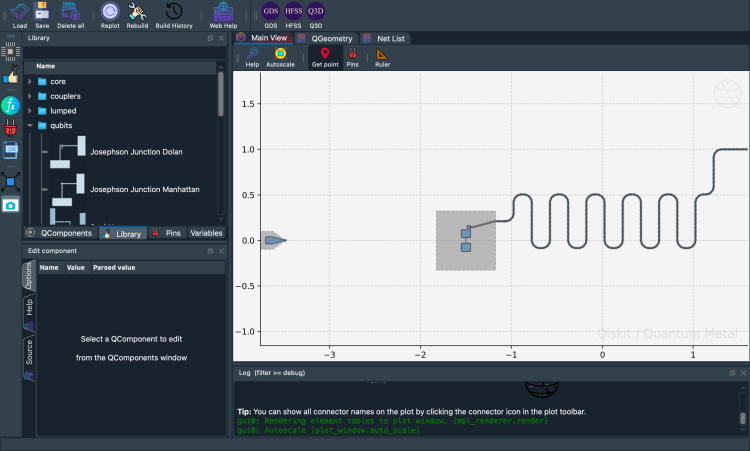

In [2]:
# One design, four components. Same names we'll use throughout the notebook.

q1 = TransmonPocket(design, "Q1", options=dict(
    pos_x="-1.5 mm", pos_y="0 mm",
    pad_width="103 um", pad_gap="60 um", inductor_width="20 um",
    connection_pads=dict(readout=dict(loc_W=+1, loc_H=+1,
                                      pad_gap="15 um", pad_width="40 um")),
))

otg = OpenToGround(design, "open_term",
    options=dict(pos_x="+1.5 mm", pos_y="+1.0 mm", orientation="180"))

res = RouteMeander(design, "readout_res", options=dict(
    pin_inputs=dict(start_pin=dict(component="Q1", pin="readout"),
                    end_pin=dict(component="open_term", pin="open")),
    total_length="8.6 mm", fillet="90 um",
    lead=dict(start_straight="0.1 mm", end_straight="0.1 mm"),
    meander=dict(asymmetry="0 um"),
))

xy = LaunchpadWirebond(design, "xy_drive",
    options=dict(pos_x="-3.5 mm", pos_y="0 mm", orientation="0"))

design.overwrite_enabled = True  # Allow overwriting components with new ones

gui.rebuild()
gui.autoscale()
gui.screenshot()


Transmon qubit (left-of-centre), meandered λ/4 readout resonator winding toward the upper-right open termination, XY-drive launchpad on the left edge. About 10 lines of Python. The four objects we'll refer to from here on:

- `q1` — the transmon
- `otg` — the open-to-ground termination
- `res` — the readout resonator
- `xy` — the XY-drive launchpad

Now let's walk through why each piece looks the way it does.


## 1. Why we need a Josephson junction

A linear LC oscillator has equally-spaced energy levels: $\omega, 2\omega, 3\omega, \dots$ You can't isolate a single transition — the spacings are identical. No qubit.

A Josephson junction is a thin (~1 nm) insulating barrier between two superconductors. Cooper pairs tunnel coherently, with current–phase relation

$$ I(\varphi) = I_c \sin(\varphi),\qquad U(\varphi) = -E_J \cos(\varphi). $$

The cosine potential — *nonlinear* in $\varphi$ — gives an anharmonic energy ladder. Visually:


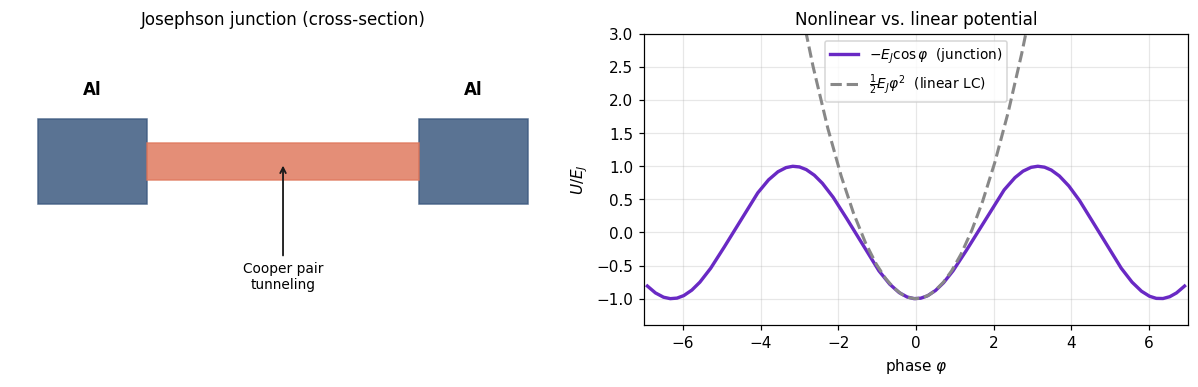

In [3]:
# Junction sketch + cosine vs. parabolic potential.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))

# Left: stylised cross-section of an Al/AlOx/Al junction
axL.set_xlim(-1, 1); axL.set_ylim(-0.5, 0.7); axL.axis("off")
axL.add_patch(plt.Rectangle((-0.9, 0), 0.4, 0.35, color="#3D5A80", alpha=0.85))
axL.add_patch(plt.Rectangle((+0.5, 0), 0.4, 0.35, color="#3D5A80", alpha=0.85))
axL.add_patch(plt.Rectangle((-0.5, 0.10), 1.0, 0.15, color="#E07A5F", alpha=0.85))
axL.text(-0.7, 0.45, "Al", ha="center", fontsize=11, fontweight="bold")
axL.text(+0.7, 0.45, "Al", ha="center", fontsize=11, fontweight="bold")
axL.text( 0.0, 0.30, "AlOₓ", ha="center", fontsize=9, color="white")
axL.annotate("Cooper pair\ntunneling", xy=(0.0, 0.17), xytext=(0.0, -0.35),
             ha="center", fontsize=9,
             arrowprops=dict(arrowstyle="->", lw=1.2, color="#1a1a1a"))
axL.set_title("Josephson junction (cross-section)", fontsize=11)

# Right: cosine vs parabolic potential
phi = np.linspace(-2.2*np.pi, 2.2*np.pi, 400)
axR.plot(phi, -np.cos(phi), lw=2.2, color="#6929C4",
         label=r"$-E_J \cos\varphi$  (junction)")
axR.plot(phi, -1 + 0.5*phi**2, lw=2.0, ls="--", color="#888",
         label=r"$\frac{1}{2}E_J\varphi^2$  (linear LC)")
axR.set_xlabel(r"phase $\varphi$"); axR.set_ylabel(r"$U / E_J$")
axR.set_title("Nonlinear vs. linear potential", fontsize=11)
axR.grid(True, alpha=0.3); axR.legend(loc="upper center", fontsize=9)
axR.set_xlim(-7, 7); axR.set_ylim(-1.4, 3.0)

plt.tight_layout()
qm.show_inline(fig)


Left: physical structure — two Al electrodes separated by a ~1 nm AlOₓ tunnel barrier. Right: the cosine potential (purple) vs. its parabolic Taylor-expansion approximation (grey). For small oscillations near $\varphi=0$ they agree; further out, the cosine flattens and the level spacings shrink — that's the anharmonicity.

The anharmonicity $\alpha = E_{12} - E_{01}$ is *negative* for a transmon, typically a few hundred MHz. We can now isolate $|0\rangle \to |1\rangle$ with a pulse spectrally narrower than $|\alpha|$ — that's the qubit.

<details><summary>Where does $I_c$ come from? (Ambegaokar–Baratoff)</summary>

The critical current of a Josephson junction at $T=0$ is $I_c = \pi\Delta / (2eR_n)$, where $\Delta$ is the superconducting gap of the electrodes and $R_n$ is the room-temperature normal-state resistance. The relation lets you predict $E_J = \hbar I_c / 2e$ from a single room-temperature resistance measurement — invaluable for fab QC. For an Al/AlOx/Al junction with $\Delta \approx 180\,\mu\text{eV}$ and $R_n \sim 8\,\text{k}\Omega$, $E_J/h \sim 15$–$20$ GHz.

</details>

In Metal the junction is a tiny rectangle (~100 nm × 200 nm) drawn in a dedicated `junction` qgeometry table — treated separately by every downstream renderer.


## 2. The transmon pocket — meet `q1`

A *transmon* [Koch *et al.*, 2007] is a Josephson junction shunted by a large capacitor: the two pads visible in any transmon screenshot.

Why pad geometry matters:

- Charging energy $E_C = e^2 / 2 C_\Sigma$ is set by total capacitance $C_\Sigma$, itself set by pad area + the gap to surrounding ground. The transmon condition $E_J/E_C \gtrsim 50$ exponentially suppresses charge dispersion. Below ~50 → charge qubit (dephasing-limited); above ~50 → transmon regime.
- Pad geometry also fixes the qubit's *participation* in nearby fields — coupling to a readout resonator, drive lines, neighbours.

Highlight `q1` in the design to see it on its own:


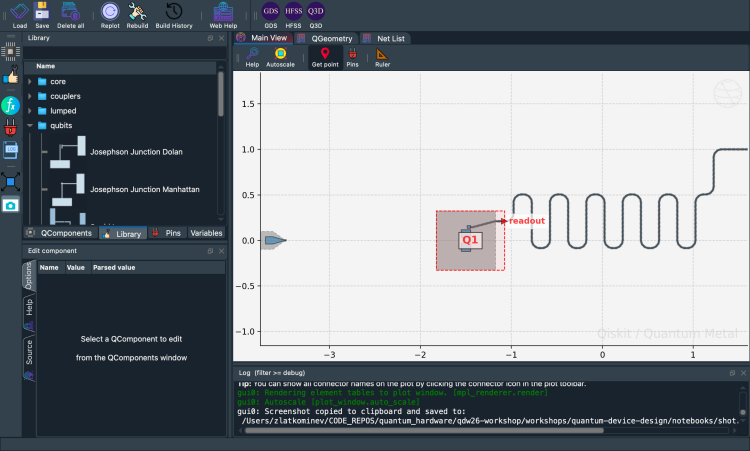

In [4]:
gui.highlight_components(["Q1"])
gui.screenshot()


- The grey *pocket* is an etched hole in the ground plane.
- The two dark blue *pads* are the capacitor plates. Bigger → more $C_\Sigma$ → lower $E_C$ → lower transmon frequency.
- The horizontal strip between the pads is the junction layer; the actual ~100 nm junction is drawn on its own qgeometry table.
- The nub at upper-right is the `readout` connection pad. Its `pad_gap` (15 µm) sets the *qubit–resonator coupling capacitance* — trades dispersive shift $\chi$ against Purcell decay.

### Discoverability — every option `TransmonPocket` accepts


In [5]:
display(TransmonPocket.get_template_options(design))


{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 'q3d_resistance': 0,
 'q3d_mesh_kw_jj': 7e-06,
 'gds_cell_name': 'my_other_junction',
 'aedt_q3d_inductance': 1e-08,
 'aedt_q3d_capacitance': 0,
 'aedt_hf

The dict above is what `q1.options` is merged on top of. Two patterns to know:

- `TransmonPocket.default_options.<field>` — class-level default. Change it and every future `TransmonPocket` you instantiate uses the new value.
- `q1.options.<field>` — instance override. Change it and only `q1` changes.

Both rerun the geometry on `design.rebuild()`.


### Hamiltonian sanity check via scqubits


In [6]:
import scqubits

# Murat's transmon_resonator.ipynb parameters — values a Q3D extraction
# of the geometry above yields, not numbers analytically derived from
# pad_width alone. The whole point of EM extraction is closing geometry →
# C_Σ → E_C → frequency.
EJ = 18.0   # GHz
EC = 0.18   # GHz (= 180 MHz)

tmon = scqubits.Transmon(EJ=EJ, EC=EC, ng=0, ncut=30)
eigs = tmon.eigenvals(evals_count=3)
f01 = eigs[1] - eigs[0]
f12 = eigs[2] - eigs[1]

print(f"E_J / E_C          = {EJ/EC:.0f}   (transmon regime if ≳ 50)")
print(f"f_01               = {f01*1000:.0f} MHz")
print(f"anharmonicity α/2π = {(f12-f01)*1000:.0f} MHz   (negative → addressable)")


E_J / E_C          = 100   (transmon regime if ≳ 50)
f_01               = 4904 MHz
anharmonicity α/2π = -197 MHz   (negative → addressable)


A ~4 GHz qubit with ~200 MHz anharmonicity. Sweet spot for fast (~20 ns), low-leakage single-qubit gates.


## ⚙️ Aside — one design, many renderers

Every component you've placed lives in one `QDesign` object. From that *single source of truth*, Quantum Metal's `QRenderer` subclasses each translate the same geometry into the format a downstream tool needs:

| Renderer | Consumes | Used for |
|---|---|---|
| `design.renderers.gds` | Layered polygons | Fabrication tape-out (KLayout-compatible) |
| `design.renderers.hfss`, `…q3d` | Boundary models + lumped-element ports | Ansys FEM / capacitance extraction (commercial) |
| `design.renderers.gmsh` + Palace | Open-source mesh + FEM | The workshop's EM path |
| ElmerFEM (via SQDMetal) | Alternative open mesher | Multiphysics |

This workshop deliberately stays on the open-source path (gmsh + Palace, surfaced via SQDMetal). The Ansys renderers are first-class in Metal — see [Tutorial 4 — Analysis](https://qiskit-community.github.io/qiskit-metal/tut/4-Analysis/) and [3.3 Render-to-Ansys](https://qiskit-community.github.io/qiskit-metal/tut/3-Renderers/3.3-Render-your-design-to-Ansys.html) — but we won't use them here.

You write the layout once; switching backends is essentially `design.renderers.<name>.render_design()`.


### Visual sweep — how `q1` changes with `pad_width`

The dimensions above are one point on a continuous design space. Sweep `pad_width` from 80 µm → 130 µm and look at the geometry side by side. We restore the workshop spec afterward so the rest of the notebook still references the canonical chip.


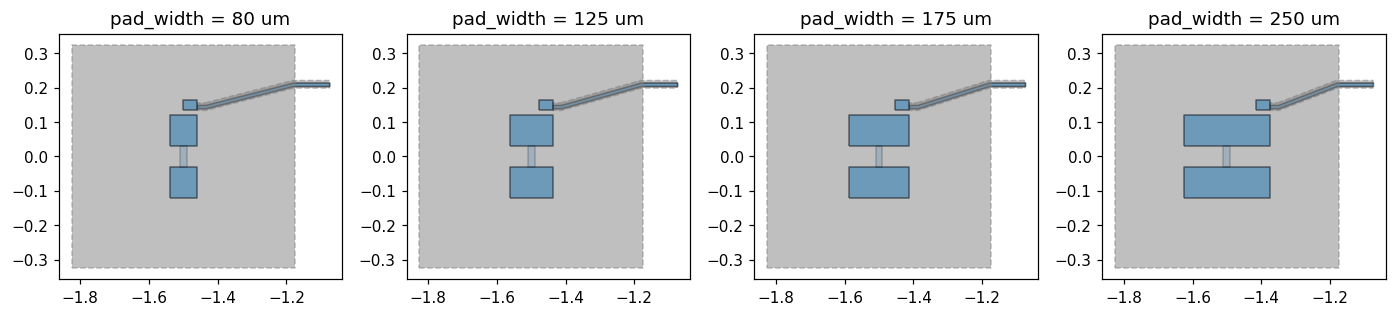

In [8]:
widths = ["80 um", "125 um", "175 um", "250 um"]
fig, axes = plt.subplots(1, len(widths), figsize=(16, 4))
for ax, w in zip(axes, widths):
    q1.options.pad_width = w
    design.rebuild()
    qm.view(design, ax=ax, components=["Q1"], title=f"pad_width = {w}")
plt.tight_layout()
qm.show_inline(fig)

q1.options.pad_width = "103 um"   # restore workshop spec
gui.rebuild()


The *frequency* shifts by O(100-200 MHz) across this range because $C_\Sigma$ scales roughly with pad area.

📖 Deeper parametric workflows: [Quantum Metal Tutorial 1.5 — Parametric design](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.5-Parametric-design---iterate-and-compare.html).


## 3a. Why CPW, why ~50 Ω — meet `res`

The readout resonator is a coplanar waveguide (CPW): a center conductor flanked by two ground strips. Two reasons CPW is the default:

- **Matched to standard microwave instrumentation** (~50 Ω). On sapphire ($\epsilon_r \approx 11.5$), Quantum Metal's default `cpw_width = 10 µm` / `cpw_gap = 6 µm` gets close to 50 Ω; the exact value depends on substrate thickness + partial-filling factor and gets pinned down by Q3D.
- **Mode confinement.** The transverse mode lives between center conductor and side grounds, mostly in the substrate. Single-layer fab, low radiation loss.

Phase velocity:

$$ v_p \approx \frac{c}{\sqrt{\epsilon_\text{eff}}},\qquad \epsilon_\text{eff} \approx \frac{1 + \epsilon_r}{2}. $$

For sapphire, $\epsilon_\text{eff} \approx 6$ → $v_p \approx 1.22 \times 10^8$ m/s.


## 3b. Why λ/4 and how length sets f_r

A quarter-wave resonator has electrical length

$$ \ell_{\lambda/4} = \frac{v_p}{4 f_r}\quad \Rightarrow\quad \ell = 8.6\,\text{mm} \Rightarrow f_r \approx 3.6\,\text{GHz}. $$

That's the resonator length the chip uses. The qubit-coupled end is the load; the far end terminates open-to-ground — the voltage antinode of the λ/4 standing wave. Visually:


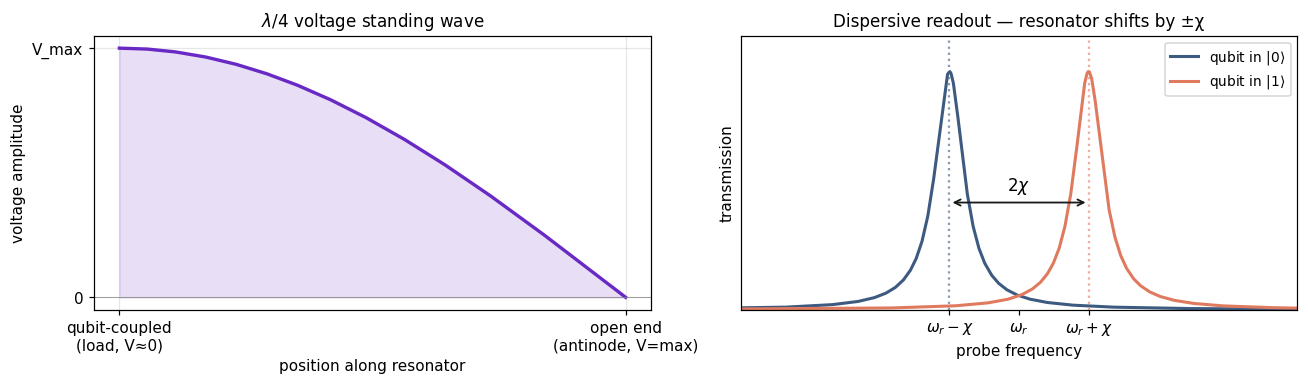

In [9]:
# λ/4 voltage mode shape + dispersive readout cartoon.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.6))

# Left: voltage standing wave along the λ/4 resonator
x = np.linspace(0, 1, 200)
V = np.cos(np.pi/2 * x)  # voltage; 0 at qubit/load end, max at open end
axL.plot(x, V, lw=2.2, color="#6929C4")
axL.fill_between(x, 0, V, alpha=0.15, color="#6929C4")
axL.axhline(0, color="#888", lw=0.5)
axL.set_xticks([0, 1])
axL.set_xticklabels(["qubit-coupled\n(load, V≈0)", "open end\n(antinode, V=max)"])
axL.set_yticks([0, 1]); axL.set_yticklabels(["0", "V_max"])
axL.set_xlabel("position along resonator"); axL.set_ylabel("voltage amplitude")
axL.set_title(r"$\lambda/4$ voltage standing wave", fontsize=11)
axL.grid(True, alpha=0.3)

# Right: two Lorentzians shifted by ±χ (dispersive readout)
f = np.linspace(-5, 5, 600)
kappa = 0.5; chi = 1.0
L_0 = (kappa/2)**2 / ((f - (-chi))**2 + (kappa/2)**2)
L_1 = (kappa/2)**2 / ((f - (+chi))**2 + (kappa/2)**2)
axR.plot(f, L_0, lw=2.0, color="#3D5A80", label=r"qubit in $|0\rangle$")
axR.plot(f, L_1, lw=2.0, color="#E07A5F", label=r"qubit in $|1\rangle$")
axR.axvline(-chi, color="#3D5A80", ls=":", alpha=0.6)
axR.axvline(+chi, color="#E07A5F", ls=":", alpha=0.6)
axR.annotate("", xy=(+chi, 0.45), xytext=(-chi, 0.45),
             arrowprops=dict(arrowstyle="<->", color="#1a1a1a", lw=1.2))
axR.text(0, 0.50, r"$2\chi$", ha="center", fontsize=11)
axR.set_xticks([-chi, 0, +chi])
axR.set_xticklabels([r"$\omega_r-\chi$", r"$\omega_r$", r"$\omega_r+\chi$"])
axR.set_yticks([]); axR.set_xlabel("probe frequency"); axR.set_ylabel("transmission")
axR.set_title("Dispersive readout — resonator shifts by ±χ", fontsize=11)
axR.legend(loc="upper right", fontsize=9); axR.set_xlim(-4, 4); axR.set_ylim(0, 1.15)

plt.tight_layout()
qm.show_inline(fig)


### Dispersive readout — what the resonator is for

Measure the qubit without destroying it: a high-Q microwave resonator capacitively coupled to the qubit shifts its frequency by $\pm\chi$ depending on the qubit state. Probe the resonator at $\omega_r$ → which Lorentzian you see tells you the qubit. The Jaynes–Cummings dispersive limit (transmon–resonator) gives

$$ \chi \approx \frac{g^2}{\Delta}\,\frac{\alpha}{\Delta + \alpha},\qquad \Delta = \omega_q - \omega_r. $$

With $\alpha < 0$ for transmons, $\chi < 0$ — quote $|\chi|$ when comparing to the resonator linewidth $\kappa$. Typical: $g/2\pi \sim 50$–$100$ MHz, $\Delta/2\pi \sim 1$–$2$ GHz, $|\chi|/2\pi \sim 1$ MHz. Want $|\chi| > \kappa$ for high-fidelity readout but $|\chi| \ll |\alpha|$ so the resonator doesn't dress higher qubit levels.

Highlight `res` and `otg` in the design:


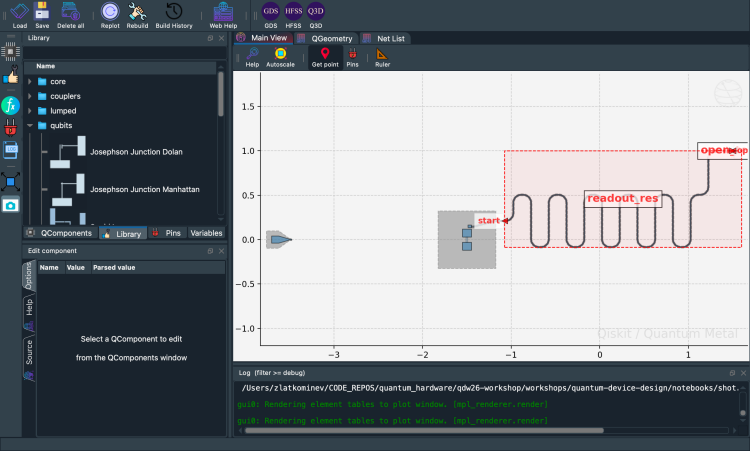

In [10]:
gui.highlight_components(["readout_res", "open_term"])
gui.screenshot()


The meandered line is the resonator — visually an order of magnitude longer than the qubit. CPW resonators dominate chip area.

| Lever | Direct effect | Trade-off |
|---|---|---|
| Resonator total length | Sets $f_r$ (longer → lower) | Chip area; crosstalk |
| Coupling pad `pad_gap` | Sets $g$ (smaller gap → bigger $g$) | Bigger $g$ → bigger $\chi$ (good readout) but more *Purcell decay* (worse $T_1$) |
| Meander geometry | Path on chip | Long parallel runs add crosstalk; sharp bends add radiation loss |

### Design variables — single source of truth for shared parameters

For multi-component / multi-qubit chips, register lengths and widths as *design-level variables* rather than hardcoding strings. Components reference variables by name; change the variable and every dependent component re-evaluates on `design.rebuild()`.


In [11]:
design.variables['cpw_total_length'] = '8.6 mm'
design.variables['cpw_width']        = '10 um'
design.variables['cpw_gap']          = '6 um'
print(design.variables)


{'cpw_width': '10 um', 'cpw_gap': '6 um', 'cpw_total_length': '8.6 mm'}


## 4. Launchpad — chip I/O, meet `xy`

To drive single-qubit gates we send a microwave pulse down a 50 Ω transmission line that terminates near the qubit. A launchpad with wirebond is the chip-edge structure that lets us bond a coax line into the on-chip CPW. The taper is a *geometric* transition (bondable cross-section → standard CPW cross-section); both ends sit at ~50 Ω so reflection stays minimal.


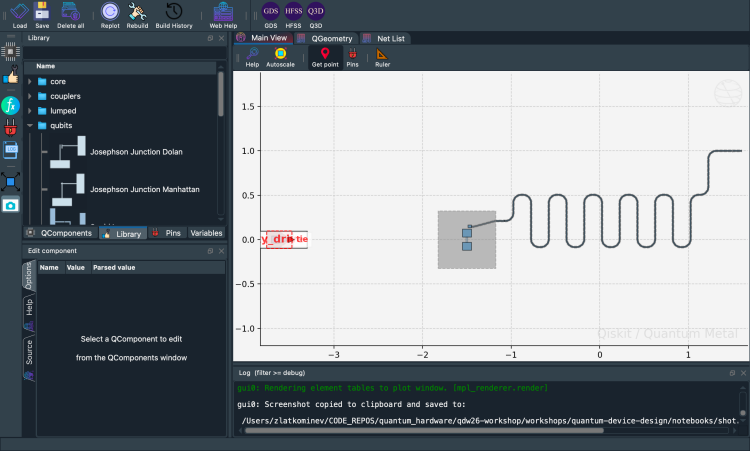

In [12]:
gui.highlight_components(["xy_drive"])
gui.screenshot()


The trapezoidal pad on the left edge is `xy`. Side tabs are bondwire landing pads (tying the pad to ground, lowering connection inductance). `04_qubit_qubit_coupling.ipynb` will route a CPW from this launchpad to a small open-stub near the qubit.


## 5. Useful interactive patterns

A handful of patterns you'll use constantly:


In [13]:
# === 1. Tweak a parameter and re-render
q1.options.pad_gap = "50 um"   # tighter cap gap → higher C_Σ → lower E_C → lower f_q
gui.rebuild()
gui.autoscale()

# === 2. Inspect parsed geometry — the numbers downstream tools see
print(f"\nQ1 footprint bounds (mm): {q1.qgeometry_bounds()}")
print("Q1 polygon table:")
display(q1.qgeometry_table("poly"))

# === 3. Pin-level view: where can other components dock to Q1?
print("\nQ1 pins:")
for pin_name, pin in q1.pins.items():
    print(f"  Q1.pin['{pin_name}']  pos={pin['middle']}  normal={pin['normal']}")

# Restore canonical pad_gap before moving on
q1.options.pad_gap = "60 um"
gui.rebuild()



Q1 footprint bounds (mm): [-1.825 -0.325 -1.075  0.325]
Q1 polygon table:


,component,name,geometry,layer,subtract,helper,chip,fillet
0,1,pad_top,"POLYGON ((-1.5515 0.025, -1.4485 0.025, -1.448...",1,False,False,main,NaN
1,1,pad_bot,"POLYGON ((-1.5515 -0.115, -1.4485 -0.115, -1.4...",1,False,False,main,NaN
2,1,rect_pk,"POLYGON ((-1.825 -0.325, -1.175 -0.325, -1.175...",1,True,False,main,NaN
3,1,readout_connector_pad,"POLYGON ((-1.4885 0.13, -1.4485 0.13, -1.4485 ...",1,False,False,main,NaN



Q1 pins:
  Q1.pin['readout']  pos=[-1.075  0.205]  normal=[1. 0.]


## 6. Save your chip + look ahead to fab


In [14]:
import pathlib

# Designs serialise to self-contained Python scripts — version-controllable.
script = design.to_python_script()
out = pathlib.Path("my_first_chip.py")
out.write_text(script)
print(f"Saved {out}  ({len(script)} bytes)")
print(f"Reproduce in any kernel with: exec(open('{out}').read())")


Saved my_first_chip.py  (2373 bytes)
Reproduce in any kernel with: exec(open('my_first_chip.py').read())


### Looking ahead — GDS export for fab

When you have a chip you actually want fabricated, Quantum Metal exports a fab-ready GDSII file:

```python
gds = design.renderers.gds
gds.options.path_filename = "../resources/Fake_Junctions.GDS"  # junction subcell
gds.export_to_gds("my_first_chip.gds")
```

[Tutorial 1.4 — Saving & exporting](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.4-Saving-Your-Chip-Design.html) walks through the full pipeline.


## Recap — the assembled chip with labels


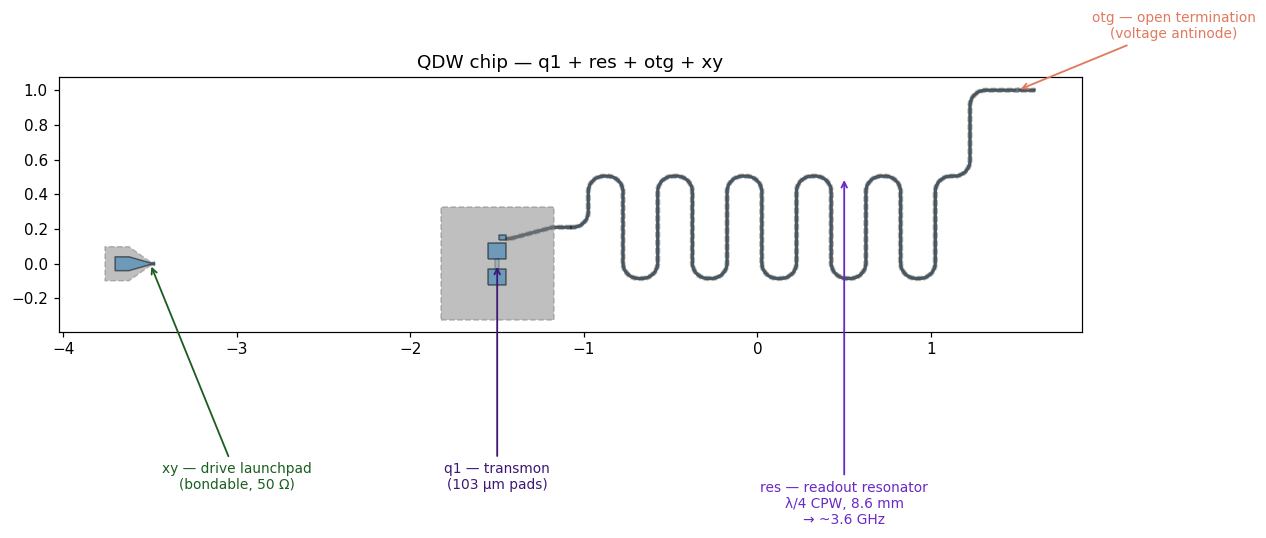

In [15]:
# Render the assembled chip + add labels via matplotlib.
fig, ax = plt.subplots(figsize=(12, 6))
qm.view(design, ax=ax, title="QDW chip — q1 + res + otg + xy")
ax.annotate("q1 — transmon\n(103 µm pads)", xy=(-1.5, 0), xytext=(-1.5, -1.3),
            ha="center", fontsize=9, color="#3D1773",
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#3D1773"))
ax.annotate("res — readout resonator\nλ/4 CPW, 8.6 mm\n→ ~3.6 GHz",
            xy=(0.5, 0.5), xytext=(0.5, -1.5),
            ha="center", fontsize=9, color="#6929C4",
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#6929C4"))
ax.annotate("otg — open termination\n(voltage antinode)",
            xy=(1.5, 1.0), xytext=(2.4, 1.3),
            ha="center", fontsize=9, color="#E07A5F",
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#E07A5F"))
ax.annotate("xy — drive launchpad\n(bondable, 50 Ω)",
            xy=(-3.5, 0), xytext=(-3.0, -1.3),
            ha="center", fontsize=9, color="#1B5E20",
            arrowprops=dict(arrowstyle="->", lw=1.2, color="#1B5E20"))
qm.show_inline(fig)


**One-line physics rationale per piece:**

- *Junction* — nonlinear element → anharmonic ladder → addressable qubit.
- *Pads* — shunt capacitance gives $E_J/E_C \gtrsim 50$, the charge-noise-insensitive transmon regime.
- *CPW resonator* — ~50 Ω, λ/4, capacitively coupled → dispersive readout via $|\chi| \sim |g^2 \alpha / \Delta(\Delta+\alpha)|$.
- *Launchpad* — bondable chip-edge I/O at 50 Ω, geometric taper to the on-chip CPW.

Same chip — `pad_width=103 µm`, `pad_gap=60 µm`, `total_length=8.6 mm` — is the device [`03_transmon_and_resonator.ipynb`](./03_transmon_and_resonator.ipynb) extracts EPR participations from with Palace.


## What's next

| | |
|---|---|
| 🔬 [`03_transmon_and_resonator.ipynb`](./03_transmon_and_resonator.ipynb) | Charge dispersion, Hamiltonian, EPR, Palace EM — *this exact chip*. |
| 🔗 [`04_qubit_qubit_coupling.ipynb`](./04_qubit_qubit_coupling.ipynb) | Two qubits + tunable bus; cross-resonance gate setup. |
| 🧩 [`05_project.ipynb`](./05_project.ipynb) | Open-ended workshop project. |

⭐ **Quantum Metal — start here:** [Docs](https://qiskit-community.github.io/qiskit-metal/) · [Tutorials index](https://qiskit-community.github.io/qiskit-metal/tut/index.html) · [Component Gallery](https://qiskit-community.github.io/qiskit-metal/qcomponents-gallery.html)

<details><summary>Full Quantum Metal resource list</summary>

- 🚀 [1.1 Quick start](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.1-Quick-start.html) · 🦅 [1.2 Bird's-eye view](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.2-Bird%27s-eye-view-of-Quantum-Metal.html) · 🏗️ [1.3 4-qubit chip](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.3-Build-a-4-qubit-chip.html) · 💾 [1.4 Saving & GDS](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.4-Saving-Your-Chip-Design.html) · 🔁 [1.5 Parametric](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.5-Parametric-design---iterate-and-compare.html)
- 🛠️ [2.31 Build your own component](https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.31-Create-a-QComponent-Basic.html)
- 📡 [Tutorial 3 — Renderers](https://qiskit-community.github.io/qiskit-metal/tut/3-Renderers/) — GDS, Ansys, gmsh
- 🔬 [Tutorial 4 — Analyses](https://qiskit-community.github.io/qiskit-metal/tut/4-Analysis/) — Hamiltonian, capacitance, EPR
- 🌐 [Headless usage](https://qiskit-community.github.io/qiskit-metal/headless-usage.html) · 🧭 [Architecture](https://qiskit-community.github.io/qiskit-metal/architecture.html)
- 🎥 [Video lectures](https://qiskit-community.github.io/qiskit-metal/videoseducation.html)
- 🌍 [Ecosystem](https://qiskit-community.github.io/qiskit-metal/ecosystem.html)

</details>

### Physics references

- Koch *et al.*, *Charge-insensitive qubit design derived from the Cooper pair box*, **Phys. Rev. A 76**, 042319 (2007). The transmon paper.
- Blais, Grimsmo, Girvin, Wallraff, *Circuit quantum electrodynamics*, **Rev. Mod. Phys. 93**, 025005 (2021). Modern cQED review.
- Krantz *et al.*, *A quantum engineer's guide to superconducting qubits*, **Appl. Phys. Rev. 6**, 021318 (2019). Survey of the whole stack.
- Pozar, *Microwave Engineering* (4th ed.) — CPW + λ/4 transmission-line theory.


## 💬 Stay connected — the Quantum Device Consortium

Workshops are starting points; the community is where the work continues. The single best place to find us — for questions, bugs, design help, or to share what you built — is:

### → [Quantum Device Consortium Discord]({{QDC_DISCORD_INVITE_URL}})

> ⚠️ **Workshop org TODO**: replace `{{QDC_DISCORD_INVITE_URL}}` with a fresh non-expiring Discord invite before publishing.

### More ways to engage — mailing list · GitHub · contribute · maintainers

- 🐛 **Bug reports / feature requests** → [`qiskit-community/qiskit-metal` issues](https://github.com/qiskit-community/qiskit-metal/issues).
- 📬 **QDW + Quantum Device Consortium news + future workshops** → contact `{{QDW_CONTACT_EMAIL}}` to be added to the mailing list. *(Workshop org: fill in.)*
- 🤝 **Contribute** — PRs welcome on `qiskit-metal`, `SQDMetal`, and the broader [ecosystem](https://qiskit-community.github.io/qiskit-metal/ecosystem.html). Easy starting points: tutorial typos, a new [QComponent](https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.31-Create-a-QComponent-Basic.html), a renderer fix.
- 🧑‍🔧 We're looking for maintainers. Quantum Metal is community-maintained and the surface area is growing. If you'd like to steward a piece, reach out on Discord or to the QDW organising team.

